## Introducción
Para entrar en contexto, en este programa se tratarán dos temas principalmente:
- La optimización de grandes archivos de datos.
- Desarrollar un sistema personalizado de recomendación basado en el contenido.

## Import
Librerías utilizadas para el desarrollo del programa.

In [142]:
import random
import numpy as np 
import pandas as pd 
import os
import ast
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import time
from scipy.stats import zscore
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from IPython.display import IFrame, display, Image
import warnings
import sys

warnings.filterwarnings("ignore")

## Problemas encontrados
Durante el desarrollo del programa de recomendación colaborativo (filtrado por contenido) han surgido una serie de problemas que se van a listar a continuación:

    - Gran volúmen de datos de los archivos CSV.
    - Dispersión de los datos.
    - Implementación del sistema de recomendación híbrido.

## Métodos necesarios

In [143]:
def arreglar_dispersion(df: pd.DataFrame, columnas, z_score_umbral: int):
    """ Convierte en nulos aquellos valores que son excesivamente 
    grandes en comparación a la media.
    
    Args:
        df (pd.Dataframe): Dataframe que se desea modificar.
        columnas: Aquellas columnas que contienen valores dispersos.
        z_score_umbral (int): Umbral de dispersión. 
    """
    for col in columnas:
        # Z-score mide cuántas desviaciones estándar se encuentra un valor respecto a la media.
        z_scores = np.abs(zscore(df[col], nan_policy='omit'))  # Calcula Z-score (da un valor de cada registro de la columna indicando cuánta desviación tiene de la media)
        df.loc[z_scores > z_score_umbral, col] = np.nan  # Sustituye atípicos con NaN (en el caso de que la desviación sea mayor que el umbral)

In [144]:
def pedir_texto_obligatorio(mensaje: str) -> str:
    """ Pide al usuario un texto no vacío.

    Args:
        mensaje (str): Mensaje del programa

    Returns:
        str: Devuelve el valor introducido por el usuario.
    """
    while True:
        valor = input(mensaje).strip()
        if valor:
            return valor
        print("Este campo no puede estar vacío. Inténtalo de nuevo.")

In [145]:
def pedir_valoracion(mensaje: str, min_val: int = 0, max_val: int = 10) -> int:
    """ Pide al usuario una valoración numérica entre min_val y max_val,
    admite coma o punto decimal y redondea al entero más cercano.

    Args:
        mensaje (str): Mensaje del programa
        min_val (int, optional): Valor mínimo de la valoración. Defaults to 0.
        max_val (int, optional): Valor máximo de la valoración. Defaults to 10.

    Returns:
        int: Devuelve la valoración indicada por el usuario.
    """
    while True:
        texto = input(mensaje).replace(',', '.').strip()
        try:
            puntuacion = float(texto)
        except ValueError:
            print("La valoración debe ser un número. Inténtalo otra vez.")
            continue

        if puntuacion < min_val or puntuacion > max_val:
            print(f"La valoración debe estar entre {min_val} y {max_val}.")
            continue

        return int(round(puntuacion))


In [146]:
def buscar_id_juego(df_info_juegos: pd.DataFrame, titulo: str) -> int | None:
    """ Busca el juego por título (sin distinguir mayúsculas/minúsculas).

    Args:
        df_info_juegos (pd.DataFrame): Dataframe con la información de los juegos de mesa.
        titulo (str): Nombre del juego a buscar.

    Returns:
        int | None: Devuelve el ID del juego o None si no lo ha encontrado.
    """
    titulo = titulo.replace(' ', '_')
    coincidencias = df_info_juegos[
        df_info_juegos['primary'].str.lower() == titulo.lower()
    ]
    if coincidencias.empty:
        return None
    return int(coincidencias.iloc[0]['id'])


In [147]:
def agregar_review(df_reviews: pd.DataFrame, df_info_juegos: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """ Agrega una nueva review a df_reviews

    Args:
        df_reviews (pd.DataFrame): Dataframe con las reviews de los usuarios.
        df_info_juegos (pd.DataFrame): Dataframe con la información de los juegos de mesa.

    Returns:
        pd.DataFrame: Devuelve el dataframe con la nueva review agregada.
    """
    usuarios_nuevos: list[str] = []
    while True:
        # Preguntar si desea agregar una nueva reseña.
        continuar = input("¿Quieres añadir una reseña? (s/n): ").strip().lower()
        if continuar != 's':
            break
        # Usuario
        usuario = pedir_texto_obligatorio("Introduce tu nombre de usuario: ")

        # Título del juego
        titulo = pedir_texto_obligatorio("Introduce el nombre del juego: ")

        # Localizar ID
        id_juego = buscar_id_juego(df_info_juegos, titulo)
        if id_juego is None:
            print(f"No existe el juego «{titulo}». Se omite esta entrada.")
        else:
            # Valoración
            valoracion = pedir_valoracion("Introduce tu valoración (1–10): ")

            # Comentario libre
            comentario = input("Escribe tu comentario: ").strip()

            # Añadir al DataFrame
            nueva_fila = {
                'user':    usuario,
                'ID':      id_juego,
                'rating':  valoracion,
                'comment': comentario
            }
            df_reviews = pd.concat(
                [df_reviews, pd.DataFrame([nueva_fila])],
                ignore_index=True
            )
            print("¡Reseña añadida correctamente!")
            
            usuarios_nuevos.append(usuario)
    
    
    return df_reviews, usuarios_nuevos

In [ ]:

def comprobar_ruta(ruta: str):
    """Comprueba que la ruta exista.

    Args:
        ruta (str): La ruta hacia el archivo.
    """
    if os.path.isfile(ruta):
        return True
    
    return False

In [149]:
def validar_dataframe(df: pd.DataFrame, columnas_req: list[str]) -> bool:
    """Valida que el dataframe no esté vacío y las columnas sean 
    las necesarias para el sistema de recomendación.

    Args:
        df (pd.DataFrame): Dataframe que se desea validar.
        columnas_req (list[str]): Lista de las columnas del dataframe 
        que son requeridas.

    Returns:
        bool: True si es válido el dataframe y False si 
        no cumple las condiciones de validación.
    """
    faltan = set(columnas_req) - set(df.columns)
    if faltan or df.empty:
        return False
    
    return True
    

Para evitar la paradoja del arranque en frío se utilizará el siguiente método que recomendará los juegos más populares.

In [150]:
def recomendacion_popular(df_info_juegos) -> pd.DataFrame:
    df_info_juegos = df_info_juegos.nlargest(5, 'average')
    return df_info_juegos

### Constantes

In [151]:
# Columnas seleccionas del dataset con la información de los juegos
INFO_JUEGO_COLS = ['id',
                   'primary',
                   'yearpublished',
                   'playingtime',
                   'boardgamecategory', 
                   'maxplayers',
                   'average']

# Columans seleccionadas de las reviews
RATING_COLS = ['user',
               'rating',
               'ID', 
               'comment']

RUTA_INFO = "../data/games_detailed_info.csv"
RUTA_REVIEWS = "../data/bgg-26m-reviews.csv"
RUTA_IMAGEN = "../recursos/peso_sin_optimizar.png"

PROBABILIDAD_FALLO = 0.2
TOP_JUEGOS = 1000
PORCENTAJE = 0.1
VOTOS_MINIMOS = 10
DELIMITADOR_Z_SCORE = 3
EJEMPLO_USUARIO = None
VALORACION_USUARIO_UMBRAL = 5


FILTRO_CATEGORIA = {
    "boardgamecategory": None
}

In [152]:
if not (comprobar_ruta(RUTA_INFO)):
    sys.exit(f"La siguiente ruta no existe: {RUTA_INFO}")
elif not (comprobar_ruta(RUTA_REVIEWS)):
    sys.exit(f"La siguiente ruta no existe: {RUTA_REVIEWS}")
elif not (comprobar_ruta(RUTA_IMAGEN)):
    sys.exit(f"La siguiente ruta no existe: {RUTA_REVIEWS}")

In [153]:
# Semilla aleatoria utilizando el tiempo del sistema
random.seed(int(time.time()))
# Permite transformar los usuarios a números enteros
label_encoder = LabelEncoder()

# Para mostrar datos de forma gráfica
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

### Lectura y optimización
En primer lugar, veamos el peso del archivo original y el consumo que hace este en memoria. Se tomó solo como prueba el archivo más pesado, ya que el proceso de optimización es similar en ambos.

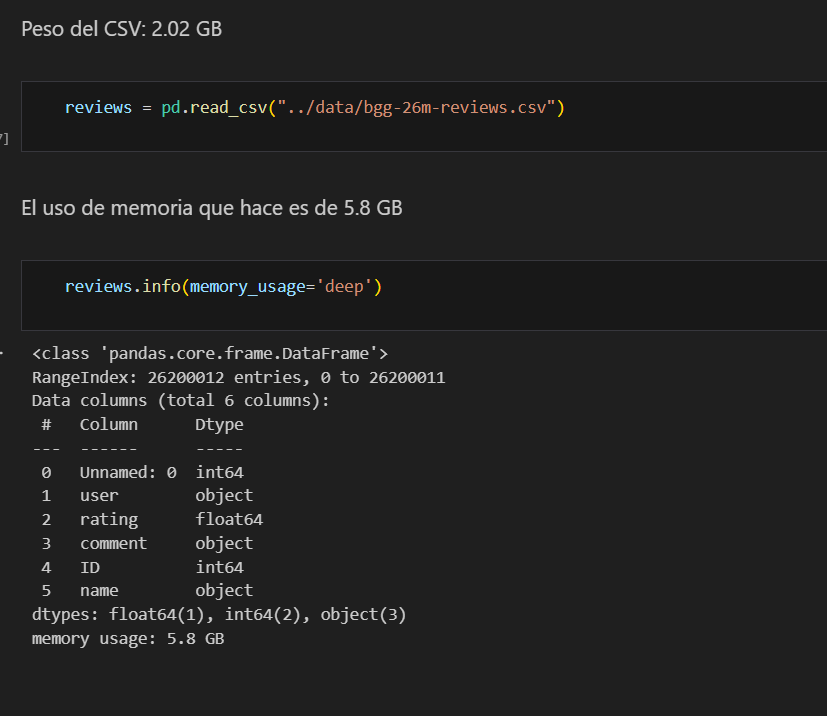

In [154]:
display(Image(filename=RUTA_IMAGEN))

A continuación, se leerán los dos archivos CSV necesarios para realizar la recomendación. El primer CSV contiene información de los juegos de mesa, pero solo se cogerán las columnas que se necesiten para realizar la recomendación y el segundo archivo que leeremos con pandas será el que contiene la valoración, la puntuación, el ID del juego y el usuario. Este último tiene un peso demasiado grande y es necesario optimizarlo para ahorrar espacio en memoria, al igual que hacemos con el primer archivo.

In [155]:
# Lectura CSV
info_juegos = pd.read_csv(RUTA_INFO,
                usecols=INFO_JUEGO_COLS, 
                dtype={'id': 'uint32', 
                        'primary': 'string', 
                        'yearpublished': 'uint16', 
                        'maxplayers': 'uint16',
                        'playingtime': 'uint32',
                        'average': 'float16'
                        })
        
if not validar_dataframe(info_juegos, INFO_JUEGO_COLS):
        raise ValueError("El dataframe no es válido. Es posible que las columnas no sean las requeridas o que el csv no tenga registros.")
         

# Solucionar dispersión, sustituye por nan
arreglar_dispersion(info_juegos, ['playingtime', 'maxplayers'], DELIMITADOR_Z_SCORE)

# Eliminar nulos, duplicados.
info_juegos = info_juegos.dropna()
info_juegos = info_juegos.drop_duplicates()

#  Eliminar espacios en blanco, mayúsculas y reduce a dos decimales la valoración media
info_juegos['primary'] = info_juegos['primary'].str.lower()
info_juegos['primary'] = info_juegos['primary'].str.replace(' ', '_')
info_juegos['average'] = info_juegos['average'].apply(lambda x: np.around(x, decimals=2))

In [156]:
# info_juegos.info()
# info_juegos.isnull().values.any()
# info_juegos.isnull().sum().sum()
# info_juegos.head(10)
info_juegos.head()

,id,primary,yearpublished,maxplayers,playingtime,boardgamecategory,average
0,30549,pandemic,2008,4.0,45.0,['Medical'],7.59
1,822,carcassonne,2000,5.0,45.0,"['City Building', 'Medieval', 'Territory Build...",7.42
2,13,catan,1995,4.0,120.0,"['Economic', 'Negotiation']",7.14
3,68448,7_wonders,2010,7.0,30.0,"['Ancient', 'Card Game', 'City Building', 'Civ...",7.73
4,36218,dominion,2008,4.0,30.0,"['Card Game', 'Medieval']",7.61


In [157]:
info_juegos.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 21097 entries, 0 to 21630
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 21097 non-null  uint32 
 1   primary            21097 non-null  string 
 2   yearpublished      21097 non-null  uint16 
 3   maxplayers         21097 non-null  float64
 4   playingtime        21097 non-null  float64
 5   boardgamecategory  21097 non-null  object 
 6   average            21097 non-null  float64
dtypes: float64(3), object(1), string(1), uint16(1), uint32(1)
memory usage: 4.2 MB


In [158]:
reviews = pd.read_csv(RUTA_REVIEWS, 
                      usecols=RATING_COLS, 
                      skiprows=lambda x: x > 0 and random.random() >= PROBABILIDAD_FALLO,
                      dtype={'user': 'string', 
                             'rating': 'float16', 
                             'ID': 'uint32',
                             'comment': 'string[pyarrow]' #  Al usar string[pyarrow] se reduce la memoria significativamente
                             }) 

if not validar_dataframe(reviews, RATING_COLS):
       raise ValueError("El dataframe no es válido. Es posible que las columnas no sean las requeridas o que el csv no tenga registros.")
       
       
reviews = reviews.dropna()
reviews = reviews.drop_duplicates(subset=["user", "ID"], keep="first")

reviews['rating'] = reviews['rating'].astype(np.int8)

Fuente de donde se investigó la forma de optimizar grandes cantidades de datos en memoria.

In [159]:
IFrame(src="https://www.pythonspeed.com", width=800, height=600)

In [160]:
reviews.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
Index: 842266 entries, 0 to 5241528
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user     842266 non-null  string
 1   rating   842266 non-null  int8  
 2   comment  842266 non-null  string
 3   ID       842266 non-null  uint32
dtypes: int8(1), string(2), uint32(1)
memory usage: 244.1 MB


In [161]:
reviews.memory_usage(deep=True)

Index        6738128
user        55550428
rating        842266
comment    189481237
ID           3369064
dtype: int64

In [162]:
reviews.head()

,user,rating,comment,ID
0,cypar7,10,"I know it says how many plays, but many, many ...",13
4,ScottM,10,"Everyone I've shown this to, gamer and non-gam...",13
5,ericleesmith,10,"One of the best games ever, and one that gets ...",13
6,andy hart,10,"So, it's a ten then. I hate to have to go with...",13
10,Tod Levi,10,"With the Seafarers Expansion, a near perfect g...",13


Se eliminan aquellos registros que no se encuentran en info_juegos.

In [163]:
# Filtra por los registros que coinciden con el id de info_juegos
reviews = reviews[reviews['ID'].isin(info_juegos['id'])]
reviews.head(4)

,user,rating,comment,ID
0,cypar7,10,"I know it says how many plays, but many, many ...",13
4,ScottM,10,"Everyone I've shown this to, gamer and non-gam...",13
5,ericleesmith,10,"One of the best games ever, and one that gets ...",13
6,andy hart,10,"So, it's a ten then. I hate to have to go with...",13


### Agregación de nuevas reviews
Se podrán añadir nuevos registros de nuevas reviews al dataframe.

In [164]:
reviews, usuarios_agregados = agregar_review(reviews, info_juegos)

### Gráfica
En la siguiente gráfica se muestra la cantidad de usuarios que valoraron con una puntuación específica. Este dato es importante para marcar un umbral de valoraciones. Se detallará más adelante.

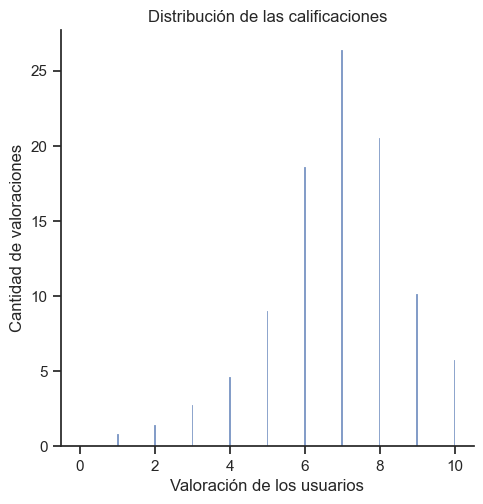

In [165]:
ax = sns.displot(data=reviews, x='rating', stat='percent', fill="blue")
ax.set(xlabel="Valoración de los usuarios",
       ylabel='Cantidad de valoraciones',
       title='Distribución de las calificaciones')

En base a la tabla vista anteriormente, se crea una tabla donde se haga la media de las valoraciones para un juego concreto y se cuente el número de usuarios que puntuaron un juego en específico.

Esto es importante para darnos cuenta de que hay juegos que fueron valorados por un único usuario y podría afectar al sistema de recomendación, ya que podrían recomendarse juegos con un 10 de valoración, pero solo fueron valorados por pocos usuarios y el juego que se recomiende, lógicamente, debería de ser uno que sea famoso entre los usuarios. 

In [166]:
# Genera una tabla agrupando por id de juego y mostrando el número de usuarios que han valorado el juego y la media total de la valoración.
rated_games = reviews.groupby("ID").agg({"rating": "mean", "user": "count"}).reset_index()
rated_games.sort_values("rating", ascending=False)

,ID,rating,user
5041,11496,10.0,1
15846,218503,10.0,1
15579,211882,10.0,1
495,604,10.0,2
13243,169320,10.0,1
...,...,...,...
8298,39124,1.0,1
16363,229902,1.0,1
8086,37224,1.0,1
16130,224793,1.0,1


### Sistema de recomendación colaborativo.
Sistema de recomendación colaborativo basado en juegos similiares que el usuario valoró positivamente.

Filtrado de aquellos juegos que tengan una cantidad mínima de votos para evitar juegos con pocas valoraciones. De esta forma, se evita hacer recomendaciones de juegos que pueden tener una alta puntuación, pero pocos usuarios han llegado a jugarlo.

In [167]:
# Media de votos 
MEDIA_VOTOS_POR_JUEGO = int(rated_games['user'].mean())

# Cantidad de votos que superan la media.
juegos_superan_media = (rated_games['user'] >= MEDIA_VOTOS_POR_JUEGO).sum()

# Cantidad de votos que deben superar el mínimo de juegos.
MIN_JUEGOS = int(len(info_juegos) * PORCENTAJE)

# Número de juegos que se van a seleccionar.
SELECCION = int(juegos_superan_media * 0.3)

# Se filtra según los votos y la cantidad de votos que supera el mínimo de votos.
if MEDIA_VOTOS_POR_JUEGO > 0 and juegos_superan_media > MIN_JUEGOS:
    rated_games = rated_games[rated_games["user"] >= MEDIA_VOTOS_POR_JUEGO].head(SELECCION) # Se toma solo un porcentaje de todas las reviews.
    
print(reviews.count())
sample_reviews = reviews[reviews['ID'].isin(rated_games['ID'])]
sample_reviews.count()



user       787543
rating     787543
comment    787543
ID         787543
dtype: int64


user       204041
rating     204041
comment    204041
ID         204041
dtype: int64

En el siguiente código liberamos espacio de la memoria, ya que el dataframe reviews no lo volvemos a utilizar a partir de aquí.

In [168]:
del reviews
import gc
gc.collect()

478

In [169]:
sample_reviews.head()

,user,rating,comment,ID
0,cypar7,10,"I know it says how many plays, but many, many ...",13
4,ScottM,10,"Everyone I've shown this to, gamer and non-gam...",13
5,ericleesmith,10,"One of the best games ever, and one that gets ...",13
6,andy hart,10,"So, it's a ten then. I hate to have to go with...",13
10,Tod Levi,10,"With the Seafarers Expansion, a near perfect g...",13


In [170]:
sample_reviews.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 204041 entries, 0 to 4876639
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   user     204041 non-null  string
 1   rating   204041 non-null  int8  
 2   comment  204041 non-null  string
 3   ID       204041 non-null  uint32
dtypes: int8(1), string(2), uint32(1)
memory usage: 52.3 MB


#### Matriz de interacción
Creación de la matriz de interacción donde el índice es el nombre del usuario, las columnas son los juegos y los valores son las valoraciones de dichos juegos por un usuario concreto

In [171]:
# Creación de la matriz de interacción. x = ID, y = user, valor = rating
games_matrix = sample_reviews.pivot_table(index='user', columns='ID', values='rating')

# Se rellenan los nulos con ceros para cálculos posteriores.
# games_matrix.fillna(0) 
games_matrix.head()


ID,1,3,5,7,9,10,11,12,13,14,...,19841,19854,19857,19947,19948,19989,19995,19996,19999,20022
user,,,,,,,,,,,,,,,,,,,,,
-Johnny-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-LucaS-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-PEDROPABLO-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-mIDE-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
-xXx-,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Usuario
Coge un usuario de forma aleatoria de los agregados o coge uno de todos los disponibles o del especificado en la constante "EJEMPLO_USUARIO"

In [172]:
if usuarios_agregados:
    user_id = random.choice(usuarios_agregados)
elif EJEMPLO_USUARIO is None:
    user_id = games_matrix.sample(n=1, axis=0).index[0]
else:
    user_id = EJEMPLO_USUARIO
    
print(user_id)

Furchtbares Gaming


Se localiza dentro de la matriz de interacción al usuario seleccionado. En caso de que el usuario no haya valorado ningún juego se le recomendarán los 5 juegos más populares.

In [173]:
user_ratings = games_matrix.loc[user_id]
user_ratings = user_ratings.dropna()
user_ratings.head()    

ID
3072    10.0
Name: Furchtbares Gaming, dtype: float64

In [174]:
len(user_ratings)

1

Se filtra por las valoraciones que sean mayores a la puntuación mínima a tener en cuenta para la recomendación.

In [175]:
juegos_valorados = user_ratings[user_ratings >= VALORACION_USUARIO_UMBRAL] # Debe ser mayor o igual que 5 para no utilizar valoraciones negativas


if juegos_valorados.empty:
    df_recomendacion_popular = recomendacion_popular(info_juegos)
    sys.exit(print(df_recomendacion_popular[['primary', 'average']]))
    

df_juegos_valorados = juegos_valorados.reset_index()
df_juegos_valorados.columns = ['ID', 'rating']
df_juegos_valorados.head()

,ID,rating
0,3072,10.0


Serie inicializada que contendrá las ponderaciones.

In [176]:
# Serie inicializada que contendrá las ponderaciones
similitud_ponderada = pd.Series(np.zeros(games_matrix.shape[1]), index=games_matrix.columns)
similitud_ponderada.head()

ID
1    0.0
3    0.0
5    0.0
7    0.0
9    0.0
dtype: float64

#### Cálculo de las ponderaciones
En este bloque se hace uso del método "corrwith()". Este método calcula el coeficiente de correlación de Pearson entre un juego valorado por el usuario objetivo y el resto de juegos de games_matrix (devolviendo una serie). Es decir, buscaría otros usuarios que puntuaron ese mismo juego y se haría la correlación de los juegos jugados por dichos usuarios y el usuario objetivo.

In [177]:
# juegos_valorados es una serie con el id de los juegos y sus valoraciones del usuario objetivo
for game_id in juegos_valorados.keys():
    # Obtiene la correlación del juego valorado del usuario objetivo con el resto de juegos de games_matrix y devolviendo una serie
    # La correlación va desde -1 a 1
    corr_series = games_matrix.corrwith(games_matrix[game_id])
    corr_series = corr_series + 1
    # Reemplazamos NaN por 0 en la correlación
    corr_series = corr_series.fillna(0)
    # Se suma esa correlación a cada juego de similitud_ponderada
    similitud_ponderada = similitud_ponderada.add(corr_series, fill_value=0)
    

similitud_ponderada = similitud_ponderada.astype(np.float16)


In [178]:
similitud_ponderada.sort_values(ascending=False).head()

ID
15511    2.0
6901     2.0
8166     2.0
16991    2.0
5895     2.0
dtype: float16

In [179]:
# Convertir en promedio ponderado para que no importe si el usuario objetivo ha valorado muchos o pocos juegos. Evita la dispersión
peso_total = len(juegos_valorados) * 2
if peso_total != 0:
    similitud_ponderada = similitud_ponderada / peso_total
    
print(similitud_ponderada.sort_values(ascending=False).head())
len(similitud_ponderada)

ID
15511    1.0
6901     1.0
8166     1.0
16991    1.0
5895     1.0
dtype: float16


1094

In [180]:
# Conversión en dataframe
df_similitud_ponderada = similitud_ponderada.reset_index()
df_similitud_ponderada.columns = ['ID', 'ponderacion']

## Análisis de sentimientos
Se hace uso de la librería NLTK que permite trabajar con textos en tareas de Procesamiento de Lenguaje Natural (PLN). Además, esta libería trae "Sentiment Analyzer VADER" que analizará los sentimientos de los textos dando un resultado positivo, negativo o neutro. Esto lo conseguimos con el método "polarity_scores()"

In [181]:
sia = SentimentIntensityAnalyzer()
sample_reviews['sentiment'] = sample_reviews['comment'].apply(
    lambda comment: (sia.polarity_scores(comment)['compound'] + 1) if isinstance(comment, str) else 0)

print(sample_reviews.head())

            user  rating                                            comment  \
0         cypar7      10  I know it says how many plays, but many, many ...   
4         ScottM      10  Everyone I've shown this to, gamer and non-gam...   
5   ericleesmith      10  One of the best games ever, and one that gets ...   
6      andy hart      10  So, it's a ten then. I hate to have to go with...   
10      Tod Levi      10  With the Seafarers Expansion, a near perfect g...   

    ID  sentiment  
0   13     1.9001  
4   13     1.0000  
5   13     1.8712  
6   13     1.9739  
10  13     1.5719  


Hacemos la media de los sentimientos y normalizamos.

In [182]:
# Se hace la media de los sentimientos
df_avg_sentiment = sample_reviews.groupby('ID')['sentiment'].mean().reset_index().rename(columns={'sentiment': 'avg_sentiment'})
df_avg_sentiment['avg_sentiment'] = df_avg_sentiment['avg_sentiment'] * 0.5 # Asegura un rango entre 0 y 1 para posteriores cálculos
df_avg_sentiment.sort_values(by='avg_sentiment', ascending=False).head()

,ID,avg_sentiment
797,7062,0.836070
1046,17851,0.827172
266,696,0.821970
912,11081,0.820503
217,490,0.815375


Eliminamos aquellos juegos de la lista que el usuario objetivo ya haya jugado, para evitar que se le recomiende un juego ya jugado.

In [183]:
user_ratings = user_ratings.index.tolist()
df_similitud_ponderada = df_similitud_ponderada[~df_similitud_ponderada['ID'].isin(user_ratings)]
df_avg_sentiment = df_avg_sentiment[~df_avg_sentiment['ID'].isin(user_ratings)]
print(len(df_similitud_ponderada))
print(len(df_avg_sentiment))

1093
1093


Filtramos para obtener la ponderación ordenada de forma descendente

In [184]:
df_similitud_ponderada = df_similitud_ponderada.sort_values(ascending=False, by='ponderacion')
df_similitud_ponderada.head()

,ID,ponderacion
290,805,1.0
1,3,1.0
126,228,1.0
1074,19370,1.0
122,221,1.0


Fusión con la información de cada juego, su ponderación y su media de sentimientos.

In [185]:
df_analizado = df_similitud_ponderada.merge(info_juegos, left_on='ID', right_on='id', how='left')
df_analizado = df_analizado.drop(['id'], axis=1)
df_analizado = df_analizado.merge(df_avg_sentiment, left_on='ID', right_on='ID', how='left')
df_analizado.head()

,ID,ponderacion,primary,yearpublished,maxplayers,playingtime,boardgamecategory,average,avg_sentiment
0,805,1.0,buffy_the_vampire_slayer:_the_game,2000,5.0,90.0,"['Horror', 'Movies / TV / Radio theme']",6.63,0.760517
1,3,1.0,samurai,1998,4.0,60.0,"['Abstract Strategy', 'Medieval']",7.45,0.763588
2,228,1.0,lunch_money,1996,4.0,20.0,"['Card Game', 'Fighting']",5.63,0.595285
3,19370,1.0,quelf,2005,8.0,60.0,"['Action / Dexterity', 'Humor', 'Party Game', ...",5.24,0.719806
4,221,1.0,ikusa,1986,5.0,360.0,"['Civil War', 'Medieval', 'Territory Building'...",7.02,0.703411


Selección las categorías jugadas por el usuario objetivo agrupadas en una única lista.

In [186]:
# La información completa de aquellos juegos valorados por el usuario objetivo
juegos_valorados_info = info_juegos[info_juegos['id'].isin(df_juegos_valorados['ID'])]


# Convierte las categorías en una lista.
game_category = juegos_valorados_info['boardgamecategory'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

FILTRO_CATEGORIA = {categoria for lista in game_category for categoria in lista}

In [187]:
print(FILTRO_CATEGORIA)

{'Wargame', 'Miniatures', 'Fighting', 'Science Fiction'}


Filtra el dataframe para que solo tenga aquellos que contengan las categorias.

In [188]:
# Construir la máscara inicial con False para todas las filas de df_analizado
mask = pd.Series(False, index=df_analizado.index)

# Para cada categoría de las valoradas por el usuario, actualiza la máscara
for categoria in FILTRO_CATEGORIA:
    mask |= df_analizado['boardgamecategory'].fillna("").str.contains(categoria, case=False, regex=True)


df_analizado = df_analizado[mask]

df_analizado.head()

,ID,ponderacion,primary,yearpublished,maxplayers,playingtime,boardgamecategory,average,avg_sentiment
2,228,1.0,lunch_money,1996,4.0,20.0,"['Card Game', 'Fighting']",5.63,0.595285
4,221,1.0,ikusa,1986,5.0,360.0,"['Civil War', 'Medieval', 'Territory Building'...",7.02,0.703411
10,700,1.0,battle_masters,1992,2.0,60.0,"['Fantasy', 'Fighting', 'Miniatures', 'Wargame']",6.29,0.705399
12,6366,1.0,dungeons_&_dragons:_the_fantasy_adventure_boar...,2003,5.0,60.0,"['Adventure', 'Exploration', 'Fantasy', 'Fight...",6.56,0.706010
13,18985,1.0,battleground,2005,2.0,60.0,"['Ancient', 'Card Game', 'Fantasy', 'Fighting'...",6.95,0.717110


### Unión de similitud ponderada y promedio de sentimientos
A continuación se le atribuirá un 80% a la similitud ponderada, un 15% al promedio de sentimientos para realizar la recomendación de juegos y un 5% al año publicado para que se muestren aquellos juegos que son más actuales.

In [189]:
max_year = df_analizado['yearpublished'].max()
year_calculado = df_analizado['yearpublished'] / max_year

df_analizado['recomendacion_calculada'] = (df_analizado['ponderacion']) * 0.8 + (df_analizado['avg_sentiment']) * 0.15 + year_calculado * 0.05

Para terminar se escoge los 5 con la recomendación más alta y se multiplica por 100 para que esté sobre 100 la recomendación.

In [190]:
df_analizado = df_analizado.nlargest(5, 'recomendacion_calculada')
df_analizado['recomendacion_calculada'] = df_analizado['recomendacion_calculada'] * 100

print(f"Recomendaciones para el usuario {user_id}")
df_analizado[['ID', 'primary', 'yearpublished', 'recomendacion_calculada']].head()

Recomendaciones para el usuario Furchtbares Gaming


,ID,primary,yearpublished,recomendacion_calculada
44,19622,a_victory_lost:_crisis_in_ukraine_1942-1943,2006,96.552498
29,11170,heroscape_master_set:_rise_of_the_valkyrie,2004,96.551869
26,1897,the_starfarers_of_catan,1999,96.118134
13,18985,battleground,2005,95.729644
42,299,de_bellis_antiquitatis:_quick_play_wargame_rul...,1990,95.593695
